In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

In [4]:
epsilons = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
Ts_all = [0, 128, 256, 512, 750, 1024, 2048]

fn = '../results/PVAFM/stochastic_gbt_gamma0.9.npz'
data = np.load(fn)

PREGRETS_by_eps = {}
for eps in epsilons:
    states = data[f"eps_{eps}"]
    pregrets = []
    for k, T in enumerate(Ts_all):
        if k == 0:
            continue  # skip random baseline row
        irewards = [reward_simulate(states[k, i], T + i, rewards_in_period)
                    for i in range(1, states.shape[1])]
        preward = compute_normalized_future_rewards(irewards, 100, 0.5, normalization=True)
        path, ireward_opt = path_opt(states[k, 0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:], 100, 0.5, normalization=True)
        pregret = (np.sum(preward_opt).item() - np.sum(preward).item()) / 100
        pregrets.append(pregret)
    PREGRETS_by_eps[eps] = pregrets

Ts_plot = Ts_all[1:]  # x-axis values (skip T=0)
print(f"Epsilons: {epsilons}")
print(f"T values: {Ts_plot}")
print(f"Pregrets per epsilon: {len(PREGRETS_by_eps[0.1])} values")

Epsilons: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
T values: [128, 256, 512, 750, 1024, 2048]
Pregrets per epsilon: 6 values


/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_39620/297563180.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("plasma", len(epsilons))


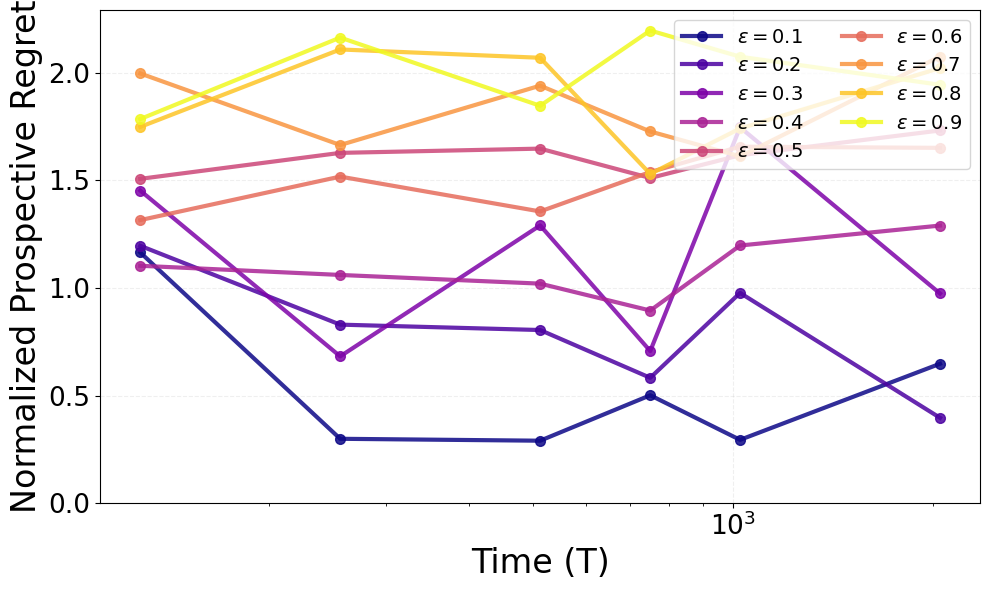

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
linewidth = 3
fontsize = 24

cmap = cm.get_cmap("plasma", len(epsilons))

for i, eps in enumerate(epsilons):
    pregrets = PREGRETS_by_eps[eps]
    color = cmap(i / (len(epsilons) - 1))
    ax.plot(Ts_plot, pregrets, color=color, lw=linewidth, marker='o',
            markersize=7, alpha=0.85, label=rf'$\epsilon = {eps}$')

ax.set_xlabel("Time (T)", fontsize=fontsize)
ax.set_ylabel("Normalized Prospective Regret", fontsize=fontsize)
ax.set_xscale('log')
ax.tick_params(axis='both', labelsize=fontsize - 5)
ax.set_ylim(bottom=0)
ax.legend(fontsize=fontsize - 10, ncol=2, loc='upper right')
ax.grid(True, linestyle='--', alpha=0.2)
fig.tight_layout()

fig.savefig("fig3_proforg_epsilon.png", dpi=150, bbox_inches='tight')
plt.show()